# Amazon Fake Review Detection System

**Course:** DATA 236 - Big Data Technologies

## Detection Layers:
1. User-Level Clustering (Spark MLlib K-Means)
2. Sentiment-Rating Inconsistency Detection
3. Text Similarity Detection (TF-IDF)
4. Review Burst Detection (Temporal Anomaly)
5. Product Rating Distribution Anomaly (Entropy)
6. Comprehensive Trust Index Calculation

## Big Data Tools:
- PySpark DataFrames
- Spark MLlib (K-Means, TF-IDF)
- DataFrame Persistence (cache)
- Window Functions

## Part 0: Environment Setup

In [ ]:
# Install required packages
!pip install pyspark vaderSentiment textblob -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.1 MB/s eta 0:00:00


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import FloatType, IntegerType, DoubleType

from pyspark.ml.feature import (
    VectorAssembler, StandardScaler,
    Tokenizer, StopWordsRemover, HashingTF, IDF, Normalizer
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All packages imported successfully!")

All packages imported successfully!


In [ ]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("FakeReviewDetection") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "64") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .getOrCreate()

print("=" * 60)
print("Spark Session Initialized")
print(f"Spark Version: {spark.version}")
print("=" * 60)

Spark Session Initialized
Spark Version: 3.5.1


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, countDistinct, year, month

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 解压zip文件
!unzip "/content/drive/MyDrive/Copy of reviews_eda_sample.parquet-20251009T224454Z-1-001.zip" -d "/content/"

# 查看解压后的文件
!ls -la /content/reviews_eda_sample.parquet/ | head -20

# 统计parquet文件数量
!ls /content/reviews_eda_sample.parquet/*.parquet | wc -l

Archive:  /content/drive/MyDrive/Copy of reviews_eda_sample.parquet-20251009T224454Z-1-001.zip
  inflating: /content/reviews_eda_sample.parquet/_SUCCESS  
  inflating: /content/reviews_eda_sample.parquet/.part-00082-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /content/reviews_eda_sample.parquet/.part-00081-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /content/reviews_eda_sample.parquet/.part-00074-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /content/reviews_eda_sample.parquet/.part-00080-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /content/reviews_eda_sample.parquet/part-00078-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet  
  inflating: /content/reviews_eda_sample.parquet/.part-00083-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /content/reviews_eda_sample.parquet/.part-00076-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.sna

In [ ]:
# 解压meta.parquet
!unzip "/content/drive/MyDrive/Copy of meta.parquet-20251009T224452Z-1-001.zip" -d "/content/"

# 确认
!ls /content/meta.parquet/ | head -10

Archive:  /content/drive/MyDrive/Copy of meta.parquet-20251009T224452Z-1-001.zip
  inflating: /content/meta.parquet/.part-00004-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /content/meta.parquet/.part-00005-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /content/meta.parquet/.part-00006-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /content/meta.parquet/._SUCCESS.crc  
  inflating: /content/meta.parquet/.part-00002-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /content/meta.parquet/_SUCCESS  
  inflating: /content/meta.parquet/.part-00007-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /content/meta.parquet/.part-00014-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /content/meta.parquet/.part-00010-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /content/meta.parquet/.part-00013-7e66f

In [ ]:
# Load Data
REVIEWS_PATH = "/content/reviews_eda_sample.parquet/"
META_PATH = "/content/meta.parquet/"

reviews_raw = spark.read.parquet(REVIEWS_PATH)
meta_raw = spark.read.parquet(META_PATH)

print(f"Reviews loaded: {reviews_raw.count():,} rows")
print(f"Meta loaded: {meta_raw.count():,} rows")

Reviews loaded: 2,193,853 rows
Meta loaded: 1,610,012 rows


## Part 1: Data Preprocessing

In [ ]:
print("\n" + "=" * 60)
print("PART 1: Data Preprocessing")
print("=" * 60)

# Select relevant columns and clean data
reviews = reviews_raw.select(
    "asin", "parent_asin", "user_id", "rating", "text", "title",
    "helpful_vote", "verified_purchase", "timestamp", "images"
).filter(
    (F.col("text").isNotNull()) &
    (F.col("user_id").isNotNull()) &
    (F.col("rating").isNotNull())
)

# Add derived features
reviews = reviews.withColumn(
    "review_length", F.length(F.col("text"))
).withColumn(
    "title_length", F.length(F.col("title"))
).withColumn(
    "has_image", F.when(F.size(F.col("images")) > 0, 1).otherwise(0)
).withColumn(
    "review_date", F.from_unixtime(F.col("timestamp") / 1000).cast("date")
).withColumn(
    "review_year", F.year(F.col("review_date"))
).withColumn(
    "review_month", F.month(F.col("review_date"))
).withColumn(
    "verified_int", F.when(F.col("verified_purchase") == True, 1).otherwise(0)
)

# Cache for performance (RDD Persistence)
reviews.cache()
review_count = reviews.count()
print(f"Cleaned reviews: {review_count:,}")

# Select relevant meta columns
meta = meta_raw.select(
    "parent_asin", "main_category", "average_rating", "rating_number", "store"
)
meta.cache()
print(f"Meta products: {meta.count():,}")

print("\nSample reviews:")
reviews.show(3, truncate=50)


PART 1: Data Preprocessing
Cleaned reviews: 2,193,853
Meta products: 1,610,012

Sample reviews:
+----------+-----------+----------------------------+------+--------------------------------------------------+-----------------------------------+------------+-----------------+-------------+------+-------------+------------+---------+-----------+-----------+------------+------------+
|      asin|parent_asin|                     user_id|rating|                                              text|                              title|helpful_vote|verified_purchase|    timestamp|images|review_length|title_length|has_image|review_date|review_year|review_month|verified_int|
+----------+-----------+----------------------------+------+--------------------------------------------------+-----------------------------------+------------+-----------------+-------------+------+-------------+------------+---------+-----------+-----------+------------+------------+
|B00F3F381A| B00HQBE8JU|AFQGD5XLVMGBLLOHSJ

In [ ]:
# Basic Statistics
print("\n" + "=" * 60)
print("Basic Statistics")
print("=" * 60)

print("\nRating Distribution:")
reviews.groupBy("rating").count().orderBy("rating").show()

print("\nVerified Purchase Distribution:")
reviews.groupBy("verified_purchase").count().show()

user_review_counts = reviews.groupBy("user_id").count()
print("\nUser Review Count Statistics:")
user_review_counts.describe("count").show()


Basic Statistics

Rating Distribution:
+------+-------+
|rating|  count|
+------+-------+
|   1.0| 267596|
|   2.0| 113128|
|   3.0| 144444|
|   4.0| 277348|
|   5.0|1391337|
+------+-------+


Verified Purchase Distribution:
+-----------------+-------+
|verified_purchase|  count|
+-----------------+-------+
|            false| 166449|
|             true|2027404|
+-----------------+-------+


User Review Count Statistics:
+-------+------------------+
|summary|             count|
+-------+------------------+
|  count|           1923112|
|   mean|1.1407827521226013|
| stddev|0.5325259712775101|
|    min|                 1|
|    max|                60|
+-------+------------------+



## Part 2: Layer 1 - User Behavior Clustering (K-Means)

In [ ]:
print("\n" + "=" * 60)
print("LAYER 1: User-Level Feature Engineering")
print("=" * 60)

# Aggregate user-level features
user_features = reviews.groupBy("user_id").agg(
    F.count("*").alias("review_count"),
    F.countDistinct("parent_asin").alias("unique_products"),
    F.avg("rating").alias("avg_rating"),
    F.stddev("rating").alias("rating_std"),
    F.min("rating").alias("min_rating"),
    F.max("rating").alias("max_rating"),
    F.avg(F.when(F.col("rating") == 5.0, 1).otherwise(0)).alias("pct_5_star"),
    F.avg(F.when(F.col("rating") == 1.0, 1).otherwise(0)).alias("pct_1_star"),
    F.avg(F.when((F.col("rating") == 5.0) | (F.col("rating") == 1.0), 1).otherwise(0)).alias("pct_extreme"),
    F.avg("review_length").alias("avg_review_length"),
    F.stddev("review_length").alias("review_length_std"),
    F.avg("helpful_vote").alias("avg_helpful_votes"),
    F.sum("helpful_vote").alias("total_helpful_votes"),
    F.avg("verified_int").alias("pct_verified"),
    F.avg("has_image").alias("pct_with_images"),
    F.min("review_date").alias("first_review_date"),
    F.max("review_date").alias("last_review_date"),
    F.countDistinct("review_date").alias("active_days")
)

# Calculate review frequency
user_features = user_features.withColumn(
    "days_span",
    F.datediff(F.col("last_review_date"), F.col("first_review_date")) + 1
).withColumn(
    "review_frequency",
    F.when(F.col("days_span") > 0, F.col("review_count") / F.col("days_span")).otherwise(F.col("review_count"))
)

# Fill nulls
user_features = user_features.fillna({
    "rating_std": 0.0, "review_length_std": 0.0, "avg_helpful_votes": 0.0,
    "total_helpful_votes": 0, "pct_with_images": 0.0
})

user_features.cache()
print(f"Total unique users: {user_features.count():,}")

print("\nUser Features Sample:")
user_features.select(
    "user_id", "review_count", "avg_rating", "pct_5_star",
    "pct_verified", "avg_review_length", "review_frequency"
).show(5, truncate=False)


LAYER 1: User-Level Feature Engineering
Total unique users: 1,923,112

User Features Sample:
+----------------------------+------------+----------+------------------+------------+-----------------+---------------------+
|user_id                     |review_count|avg_rating|pct_5_star        |pct_verified|avg_review_length|review_frequency     |
+----------------------------+------------+----------+------------------+------------+-----------------+---------------------+
|AEXRZJT6XAECMM7UGE4W7YLZGQZA|2           |4.5       |0.5               |0.5         |577.5            |0.0019212295869356388|
|AEOSZ6L64KZGPERIUEAOHRFJ4T6Q|3           |4.0       |0.3333333333333333|1.0         |444.3333333333333|9.637006103437199E-4 |
|AGBDA65QJPTBN3VIC6YRASGEVJGQ|1           |2.0       |0.0               |1.0         |367.0            |1.0                  |
|AHIR2ULJJA27MWQ3BKIPDGDWGKMA|1           |3.0       |0.0               |1.0         |141.0            |1.0                  |
|AGJK4ARRFHDWJTFM

In [ ]:
print("\n" + "=" * 60)
print("LAYER 1: User Behavior Clustering (K-Means)")
print("=" * 60)

# Filter active users (>= 3 reviews)
active_users = user_features.filter(F.col("review_count") >= 3)
print(f"Active users (>=3 reviews): {active_users.count():,}")

# Select features for clustering
cluster_features = [
    "review_count", "avg_rating", "rating_std", "pct_5_star", "pct_1_star",
    "pct_extreme", "avg_review_length", "avg_helpful_votes", "pct_verified", "review_frequency"
]

# Build ML Pipeline
assembler = VectorAssembler(inputCols=cluster_features, outputCol="features_raw", handleInvalid="skip")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model = prep_pipeline.fit(active_users)
user_data_scaled = prep_model.transform(active_users)

print("Feature scaling completed!")


LAYER 1: User Behavior Clustering (K-Means)
Active users (>=3 reviews): 43,974
Feature scaling completed!


In [ ]:
# Find Optimal K (Elbow Method + Silhouette)
print("\n--- Finding Optimal K ---")

k_values = range(2, 9)
wssse_values = []
silhouette_values = []

evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="features", metricName="silhouette")

for k in k_values:
    kmeans = KMeans(k=k, seed=42, featuresCol="features", predictionCol="cluster")
    model = kmeans.fit(user_data_scaled)
    wssse = model.summary.trainingCost
    wssse_values.append(wssse)
    predictions = model.transform(user_data_scaled)
    silhouette = evaluator.evaluate(predictions)
    silhouette_values.append(silhouette)
    print(f"K={k}: WSSSE={wssse:,.0f}, Silhouette={silhouette:.4f}")

optimal_k = list(k_values)[np.argmax(silhouette_values)]
print(f"\n*** Optimal K based on Silhouette: {optimal_k} ***")


--- Finding Optimal K ---
K=2: WSSSE=332,868, Silhouette=0.4032
K=3: WSSSE=293,356, Silhouette=0.4276
K=4: WSSSE=248,643, Silhouette=0.4021
K=5: WSSSE=226,859, Silhouette=0.4175
K=6: WSSSE=213,519, Silhouette=0.3464
K=7: WSSSE=203,284, Silhouette=0.3364
K=8: WSSSE=173,070, Silhouette=0.4432

*** Optimal K based on Silhouette: 8 ***


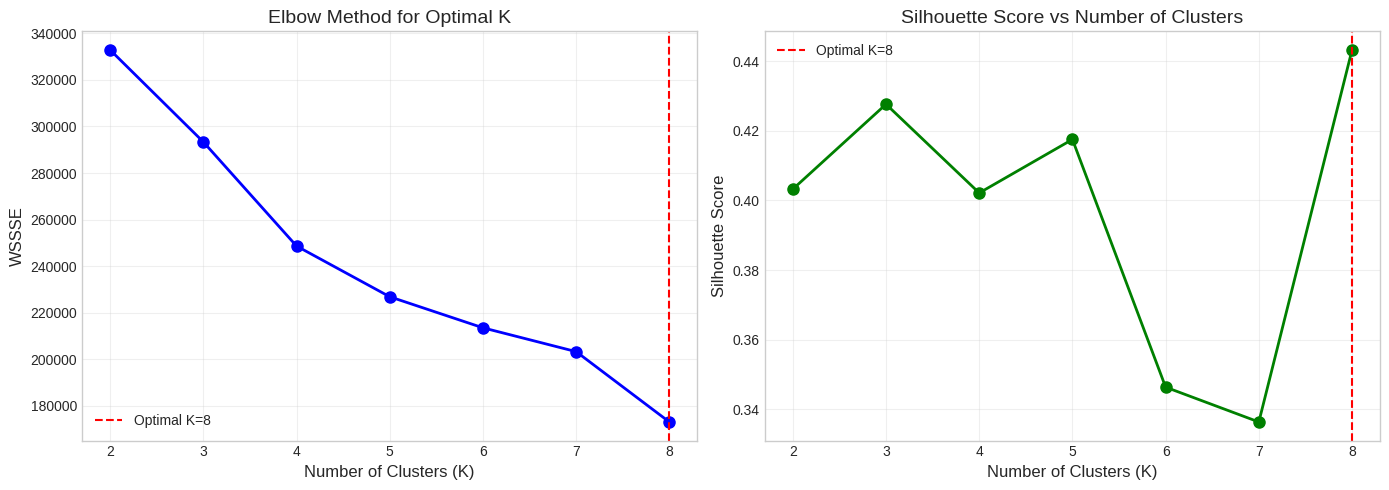

In [ ]:
# Elbow and Silhouette Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), wssse_values, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WSSSE', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_values), silhouette_values, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Train Final K-Means Model
print(f"\n--- Training Final K-Means with K={optimal_k} ---")

kmeans_final = KMeans(k=optimal_k, seed=42, featuresCol="features", predictionCol="user_cluster", maxIter=100)
kmeans_model = kmeans_final.fit(user_data_scaled)
user_clustered = kmeans_model.transform(user_data_scaled)

# Analyze clusters
cluster_stats = user_clustered.groupBy("user_cluster").agg(
    F.count("*").alias("user_count"),
    F.avg("review_count").alias("avg_reviews"),
    F.avg("avg_rating").alias("avg_rating"),
    F.avg("pct_5_star").alias("avg_5star_pct"),
    F.avg("pct_1_star").alias("avg_1star_pct"),
    F.avg("pct_verified").alias("avg_verified_pct"),
    F.avg("avg_review_length").alias("avg_review_len"),
    F.avg("review_frequency").alias("avg_frequency"),
    F.avg("avg_helpful_votes").alias("avg_helpful")
).orderBy("user_cluster")

print("\nCluster Statistics:")
cluster_stats.show()

cluster_stats_pd = cluster_stats.toPandas()


--- Training Final K-Means with K=8 ---

Cluster Statistics:
+------------+----------+------------------+------------------+-------------------+--------------------+------------------+------------------+--------------------+-------------------+
|user_cluster|user_count|       avg_reviews|        avg_rating|      avg_5star_pct|       avg_1star_pct|  avg_verified_pct|    avg_review_len|       avg_frequency|        avg_helpful|
+------------+----------+------------------+------------------+-------------------+--------------------+------------------+------------------+--------------------+-------------------+
|           0|     12893|3.4037849996121925|               5.0|                1.0|                 0.0|0.9523139758713325|213.90154902245473|0.019444418602653134| 0.8634502005100394|
|           1|      3780| 3.712169312169312|3.7095273553606867| 0.6501304258645529|  0.3018058271828112|0.9201387090275974| 306.3133916928163|0.009491274542789224| 1.6849387649387648|
|           2|    

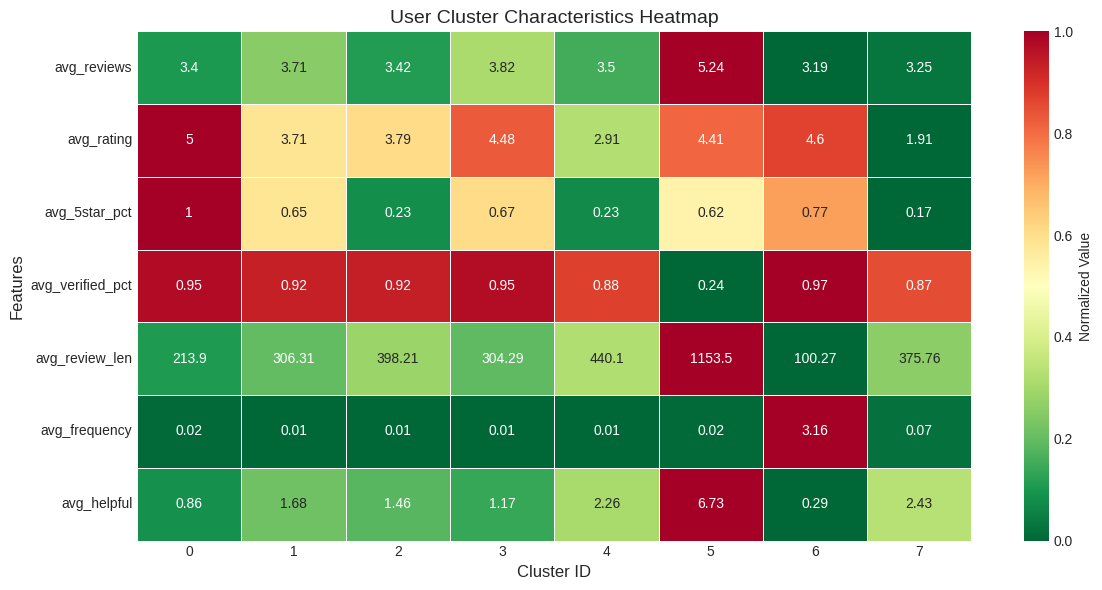

In [ ]:
# Cluster Heatmap Visualization
heatmap_cols = ['avg_reviews', 'avg_rating', 'avg_5star_pct', 'avg_verified_pct',
                'avg_review_len', 'avg_frequency', 'avg_helpful']
heatmap_data = cluster_stats_pd.set_index('user_cluster')[heatmap_cols]
heatmap_normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_normalized.T, annot=heatmap_data.T.round(2), cmap='RdYlGn_r',
    fmt='g', linewidths=0.5, cbar_kws={'label': 'Normalized Value'}
)
plt.title('User Cluster Characteristics Heatmap', fontsize=14)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Running PCA for 2D visualization...


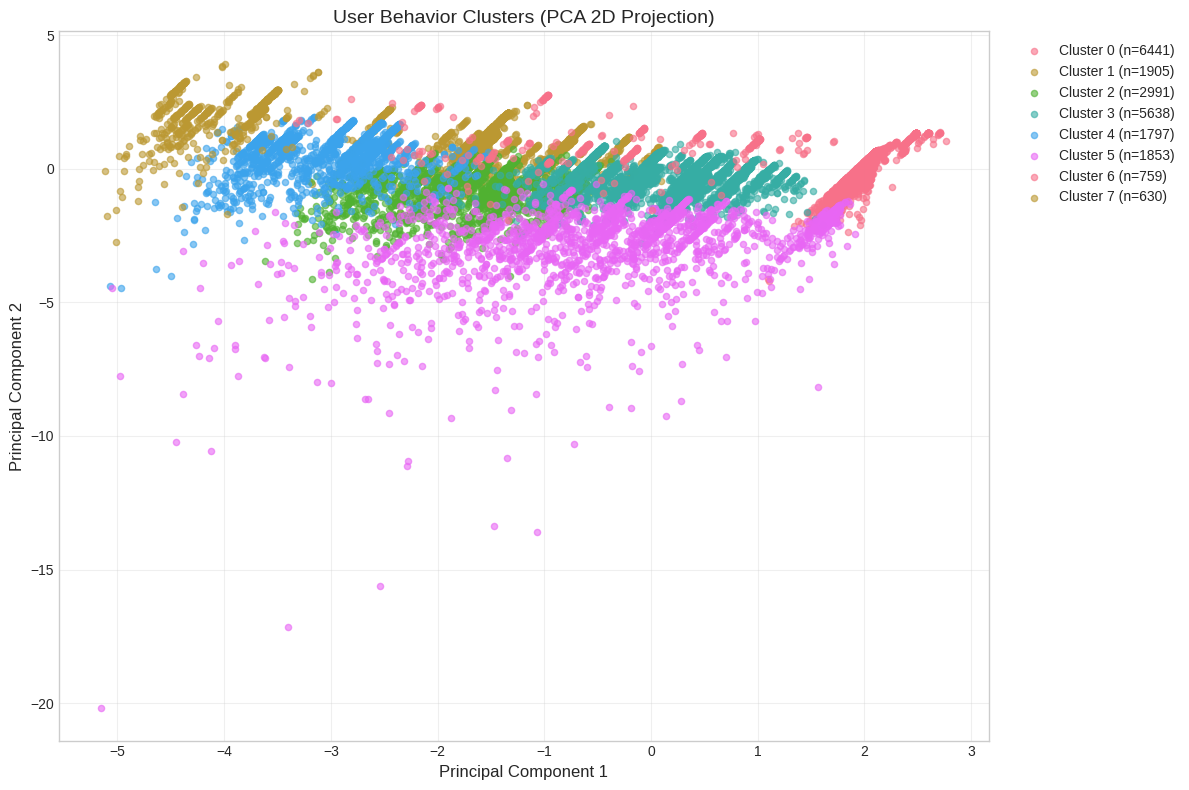


PCA Explained Variance:
  PC1: 33.26%
  PC2: 16.42%
  Total: 49.67%


In [ ]:
# Cluster Visualization - PCA 2D Scatter Plot
from pyspark.ml.feature import PCA
from pyspark.sql.types import FloatType

print("Running PCA for 2D visualization...")

# PCA降维到2D
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(user_data_scaled)
user_pca = pca_model.transform(user_clustered)

# 提取PCA坐标
@udf(FloatType())
def get_pc1(v):
    return float(v[0])

@udf(FloatType())
def get_pc2(v):
    return float(v[1])

user_pca = user_pca.withColumn("pc1", get_pc1(F.col("pca_features"))) \
                   .withColumn("pc2", get_pc2(F.col("pca_features")))

# 采样可视化
plot_data = user_pca.select("pc1", "pc2", "user_cluster", "is_suspicious_cluster") \
    .sample(fraction=0.5, seed=42).toPandas()

# 绘制散点图
plt.figure(figsize=(12, 8))

for i in range(optimal_k):
    cluster_data = plot_data[plot_data['user_cluster'] == i]
    plt.scatter(cluster_data['pc1'], cluster_data['pc2'],
                label=f'Cluster {i} (n={len(cluster_data)})',
                alpha=0.6, s=20)

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('User Behavior Clusters (PCA 2D Projection)', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印解释方差
print(f"\nPCA Explained Variance:")
print(f"  PC1: {pca_model.explainedVariance[0]:.2%}")
print(f"  PC2: {pca_model.explainedVariance[1]:.2%}")
print(f"  Total: {sum(pca_model.explainedVariance):.2%}")

In [ ]:
# Identify Suspicious Clusters
print("\n--- Identifying Suspicious Clusters ---")

suspicious_clusters = cluster_stats.filter(
    ((F.col("avg_5star_pct") > 0.7) & (F.col("avg_verified_pct") < 0.5)) |
    ((F.col("avg_frequency") > 0.3) & (F.col("avg_review_len") < 150)) |
    ((F.col("avg_5star_pct") > 0.85) & (F.col("avg_helpful") < 0.3))
).select("user_cluster")

suspicious_cluster_ids = [row.user_cluster for row in suspicious_clusters.collect()]
print(f"Suspicious Cluster IDs: {suspicious_cluster_ids}")

user_clustered = user_clustered.withColumn(
    "is_suspicious_cluster",
    F.when(F.col("user_cluster").isin(suspicious_cluster_ids), 1).otherwise(0)
)

suspicious_user_count = user_clustered.filter(F.col("is_suspicious_cluster") == 1).count()
total_clustered = user_clustered.count()
print(f"Suspicious users: {suspicious_user_count:,} ({suspicious_user_count/total_clustered*100:.1f}%)")


--- Identifying Suspicious Clusters ---
Suspicious Cluster IDs: [6]
Suspicious users: 1,552 (3.5%)


## Part 3: Layer 2 - Sentiment Analysis

In [ ]:
print("\n" + "=" * 60)
print("LAYER 2: Sentiment-Rating Inconsistency Detection")
print("=" * 60)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyspark.sql.functions import udf

analyzer = SentimentIntensityAnalyzer()

@udf(FloatType())
def get_sentiment(text):
    if text is None or len(str(text).strip()) == 0:
        return 0.0
    try:
        scores = analyzer.polarity_scores(str(text))
        return float(scores['compound'])
    except:
        return 0.0

# Sample 30% for sentiment analysis
reviews_sample = reviews.sample(fraction=0.3, seed=42)
reviews_sentiment = reviews_sample.withColumn("sentiment_score", get_sentiment(F.col("text")))

print(f"Sentiment analysis on {reviews_sentiment.count():,} reviews")

# Calculate rating-sentiment gap
reviews_sentiment = reviews_sentiment.withColumn(
    "rating_normalized", (F.col("rating") - 3) / 2
).withColumn(
    "rating_sentiment_gap", F.abs(F.col("rating_normalized") - F.col("sentiment_score"))
).withColumn(
    "suspicious_sentiment",
    F.when((F.col("rating") == 5.0) & (F.col("sentiment_score") < -0.1), 1)
    .when((F.col("rating") == 1.0) & (F.col("sentiment_score") > 0.3), 1)
    .otherwise(0)
)

suspicious_sentiment_count = reviews_sentiment.filter(F.col("suspicious_sentiment") == 1).count()
print(f"Reviews with suspicious sentiment: {suspicious_sentiment_count:,}")

reviews_sentiment.cache()

print("\nExamples of Suspicious Sentiment (5-star but negative text):")
reviews_sentiment.filter(
    (F.col("rating") == 5.0) & (F.col("sentiment_score") < -0.1)
).select("rating", "sentiment_score", "text").show(3, truncate=80)


LAYER 2: Sentiment-Rating Inconsistency Detection
Sentiment analysis on 658,684 reviews
Reviews with suspicious sentiment: 31,683

Examples of Suspicious Sentiment (5-star but negative text):
+------+---------------+--------------------------------------------------------------------------------+
|rating|sentiment_score|                                                                            text|
+------+---------------+--------------------------------------------------------------------------------+
|   5.0|        -0.1759|                                                       You get what you pay for!|
|   5.0|        -0.3818|I purchased a Lenovo SA 120 external HD box that came with fake caddies.  I d...|
|   5.0|        -0.6759|                                          Nothing but the best when you buy Bose|
+------+---------------+--------------------------------------------------------------------------------+
only showing top 3 rows



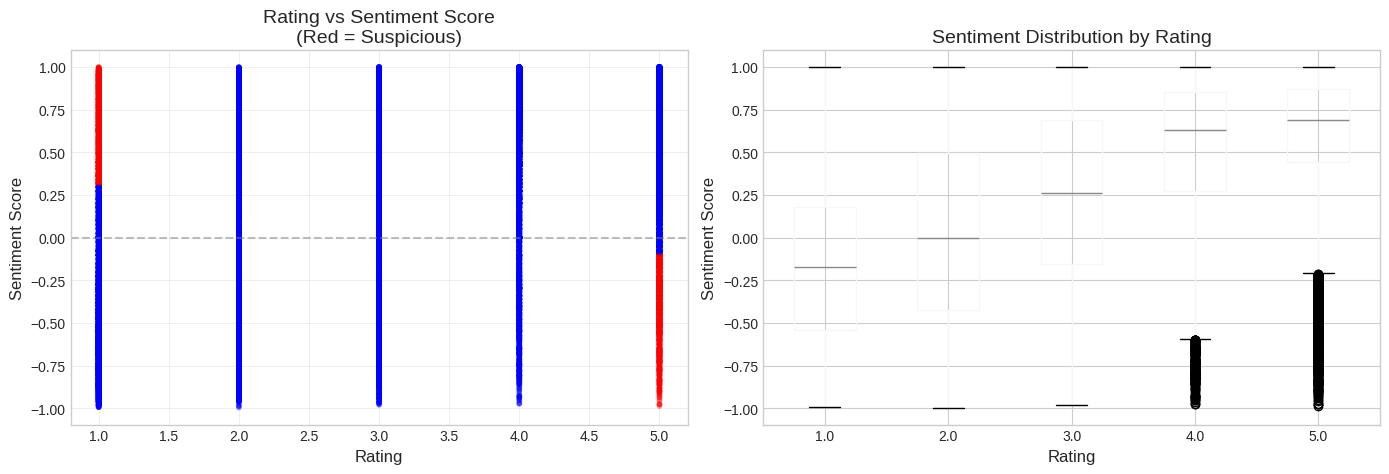

In [ ]:
# Sentiment Visualization
sentiment_pd = reviews_sentiment.select(
    "rating", "sentiment_score", "suspicious_sentiment"
).sample(fraction=0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['blue' if x == 0 else 'red' for x in sentiment_pd['suspicious_sentiment']]
axes[0].scatter(sentiment_pd['rating'], sentiment_pd['sentiment_score'], c=colors, alpha=0.3, s=10)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Sentiment Score', fontsize=12)
axes[0].set_title('Rating vs Sentiment Score\n(Red = Suspicious)', fontsize=14)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

sentiment_pd.boxplot(column='sentiment_score', by='rating', ax=axes[1])
axes[1].set_xlabel('Rating', fontsize=12)
axes[1].set_ylabel('Sentiment Score', fontsize=12)
axes[1].set_title('Sentiment Distribution by Rating', fontsize=14)
plt.suptitle('')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Layer 3 - Text Similarity Detection (TF-IDF)

In [ ]:
print("\n" + "=" * 60)
print("LAYER 3: Text Similarity Detection (TF-IDF)")
print("=" * 60)

# Sample for TF-IDF
reviews_text = reviews.select("user_id", "parent_asin", "text", "rating") \
    .filter(F.col("text").isNotNull()) \
    .sample(fraction=0.2, seed=42)

print(f"Processing {reviews_text.count():,} reviews for text similarity")

# Build TF-IDF Pipeline
tokenizer = Tokenizer(inputCol="text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashingTF = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=1000)
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
normalizer = Normalizer(inputCol="tfidf_features", outputCol="norm_features", p=2.0)

tfidf_pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, normalizer])
tfidf_model = tfidf_pipeline.fit(reviews_text)
reviews_tfidf = tfidf_model.transform(reviews_text)

print("TF-IDF transformation completed!")


LAYER 3: Text Similarity Detection (TF-IDF)
Processing 439,023 reviews for text similarity
TF-IDF transformation completed!


In [ ]:
# Detect Duplicate/Similar Reviews per User
print("\n--- Detecting Similar Reviews per User ---")

from pyspark.sql.functions import collect_list

user_vectors = reviews_tfidf.groupBy("user_id").agg(
    F.count("*").alias("review_count"),
    collect_list("norm_features").alias("vectors")
)
user_vectors = user_vectors.filter(F.col("review_count") >= 2)

@udf(FloatType())
def calc_avg_similarity(vectors):
    if vectors is None or len(vectors) < 2:
        return 0.0
    try:
        total_sim = 0.0
        count = 0
        for i in range(len(vectors)):
            for j in range(i+1, len(vectors)):
                v1 = vectors[i].toArray()
                v2 = vectors[j].toArray()
                sim = float(np.dot(v1, v2))
                total_sim += sim
                count += 1
        return total_sim / count if count > 0 else 0.0
    except:
        return 0.0

user_similarity = user_vectors.withColumn("avg_text_similarity", calc_avg_similarity(F.col("vectors")))

high_similarity_threshold = 0.5
suspicious_text_users = user_similarity.filter(F.col("avg_text_similarity") > high_similarity_threshold)

print(f"Users with high text similarity (>{high_similarity_threshold}): {suspicious_text_users.count():,}")

print("\nTop users by text similarity:")
user_similarity.orderBy(F.desc("avg_text_similarity")).show(10)

user_similarity.cache()


--- Detecting Similar Reviews per User ---
Users with high text similarity (>0.5): 408

Top users by text similarity:
+--------------------+------------+--------------------+-------------------+
|             user_id|review_count|             vectors|avg_text_similarity|
+--------------------+------------+--------------------+-------------------+
|AEBBQZB3XBTEXTWHP...|           2|[(1000,[168],[1.0...|                1.0|
|AES7SMUQKKV4J6FUQ...|           2|[(1000,[538,676],...|                1.0|
|AE72A4LFUT6TLJKOL...|           2|[(1000,[112,168,2...|                1.0|
|AFDL65Q7ESAYS2Q54...|           2|[(1000,[591],[1.0...|                1.0|
|AE37IUAPJFXGJCLPI...|           2|[(1000,[9],[1.0])...|                1.0|
|AEW737SVGCVBJCHG3...|           2|[(1000,[73,103,15...|                1.0|
|AE755AYORMJSNXSNM...|           2|[(1000,[168,326],...|                1.0|
|AEI6QUFEI7UYTJZWO...|           2|[(1000,[46,96,272...|                1.0|
|AEECTX6NCUDX3DCYN...|           2

DataFrame[user_id: string, review_count: bigint, vectors: array<vector>, avg_text_similarity: float]

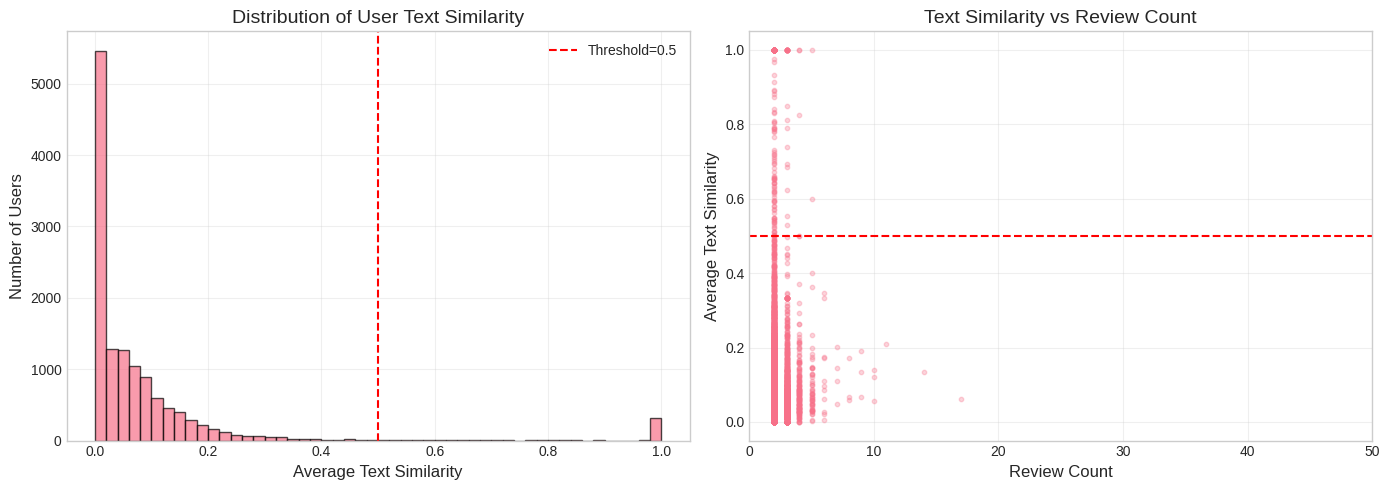

In [ ]:
# Text Similarity Visualization
similarity_pd = user_similarity.select("avg_text_similarity", "review_count").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(similarity_pd['avg_text_similarity'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=high_similarity_threshold, color='r', linestyle='--', label=f'Threshold={high_similarity_threshold}')
axes[0].set_xlabel('Average Text Similarity', fontsize=12)
axes[0].set_ylabel('Number of Users', fontsize=12)
axes[0].set_title('Distribution of User Text Similarity', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(similarity_pd['review_count'], similarity_pd['avg_text_similarity'], alpha=0.3, s=10)
axes[1].axhline(y=high_similarity_threshold, color='r', linestyle='--')
axes[1].set_xlabel('Review Count', fontsize=12)
axes[1].set_ylabel('Average Text Similarity', fontsize=12)
axes[1].set_title('Text Similarity vs Review Count', fontsize=14)
axes[1].set_xlim(0, 50)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('text_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 5: Layer 4 - Review Burst Detection

In [ ]:
print("\n" + "=" * 60)
print("LAYER 4: Review Burst Detection (Temporal Anomaly)")
print("=" * 60)

# Calculate daily review counts per product
daily_reviews = reviews.groupBy("parent_asin", "review_date").agg(F.count("*").alias("daily_count"))

# Rolling statistics using Window functions
window_spec = Window.partitionBy("parent_asin").orderBy("review_date").rowsBetween(-6, 0)

daily_reviews = daily_reviews.withColumn(
    "rolling_avg_7d", F.avg("daily_count").over(window_spec)
).withColumn(
    "rolling_std_7d", F.stddev("daily_count").over(window_spec)
)

daily_reviews = daily_reviews.withColumn(
    "rolling_std_7d", F.coalesce(F.col("rolling_std_7d"), F.lit(0.0))
).withColumn(
    "is_burst",
    F.when(F.col("daily_count") > (F.col("rolling_avg_7d") + 3 * F.col("rolling_std_7d")), 1).otherwise(0)
)

burst_products = daily_reviews.filter(F.col("is_burst") == 1).select("parent_asin").distinct()
burst_count = burst_products.count()
print(f"Products with review bursts: {burst_count:,}")

burst_reviews = reviews.join(
    daily_reviews.filter(F.col("is_burst") == 1).select("parent_asin", "review_date"),
    on=["parent_asin", "review_date"], how="inner"
)
print(f"Reviews during burst periods: {burst_reviews.count():,}")

daily_reviews.cache()

print("\nExample burst patterns:")
daily_reviews.filter(F.col("is_burst") == 1).orderBy(F.desc("daily_count")).show(10)


LAYER 4: Review Burst Detection (Temporal Anomaly)
Products with review bursts: 0
Reviews during burst periods: 0

Example burst patterns:
+-----------+-----------+-----------+--------------+--------------+--------+
|parent_asin|review_date|daily_count|rolling_avg_7d|rolling_std_7d|is_burst|
+-----------+-----------+-----------+--------------+--------------+--------+
+-----------+-----------+-----------+--------------+--------------+--------+



In [ ]:
# ============================================================
# LAYER 4: Review Burst Detection (Temporal Anomaly)
# ============================================================

print("\n" + "=" * 60)
print("LAYER 4: Review Burst Detection (Temporal Anomaly)")
print("=" * 60)

# Detect products with multiple reviews on same day
daily_reviews = reviews.groupBy("parent_asin", "review_date").agg(
    F.count("*").alias("daily_count")
)

# Flag days with 3+ reviews as burst (most products get 0-1 per day)
daily_reviews = daily_reviews.withColumn(
    "is_burst",
    F.when(F.col("daily_count") >= 3, 1).otherwise(0)
)

daily_reviews.cache()

# Count burst products
burst_products = daily_reviews.filter(F.col("is_burst") == 1).select("parent_asin").distinct()
burst_count = burst_products.count()
print(f"Products with same-day burst (>=3 reviews): {burst_count:,}")

# Show top burst patterns
print("\nTop burst patterns:")
daily_reviews.filter(F.col("is_burst") == 1) \
    .orderBy(F.desc("daily_count")) \
    .show(10)

# Get ALL reviews from products that had burst patterns
burst_reviews = reviews.join(
    burst_products,
    on="parent_asin",
    how="inner"
)
print(f"Total reviews from burst products: {burst_reviews.count():,}")


LAYER 4: Review Burst Detection (Temporal Anomaly)
Products with same-day burst (>=3 reviews): 1,874

Top burst patterns:
+-----------+-----------+-----------+--------+
|parent_asin|review_date|daily_count|is_burst|
+-----------+-----------+-----------+--------+
| B01K8B8YA8| 2018-01-25|        209|       1|
| B075X8471B| 2018-01-09|        133|       1|
| B01K8B8YA8| 2018-01-09|        117|       1|
| B075X8471B| 2018-01-25|        110|       1|
| B01K8B8YA8| 2018-03-01|        106|       1|
| B01K8B8YA8| 2018-01-26|        104|       1|
| B01K8B8YA8| 2017-07-22|        102|       1|
| B07456BG8N| 2018-01-25|        101|       1|
| B01K8B8YA8| 2017-07-12|         99|       1|
| B01K8B8YA8| 2018-01-17|         90|       1|
+-----------+-----------+-----------+--------+
only showing top 10 rows

Total reviews from burst products: 441,692


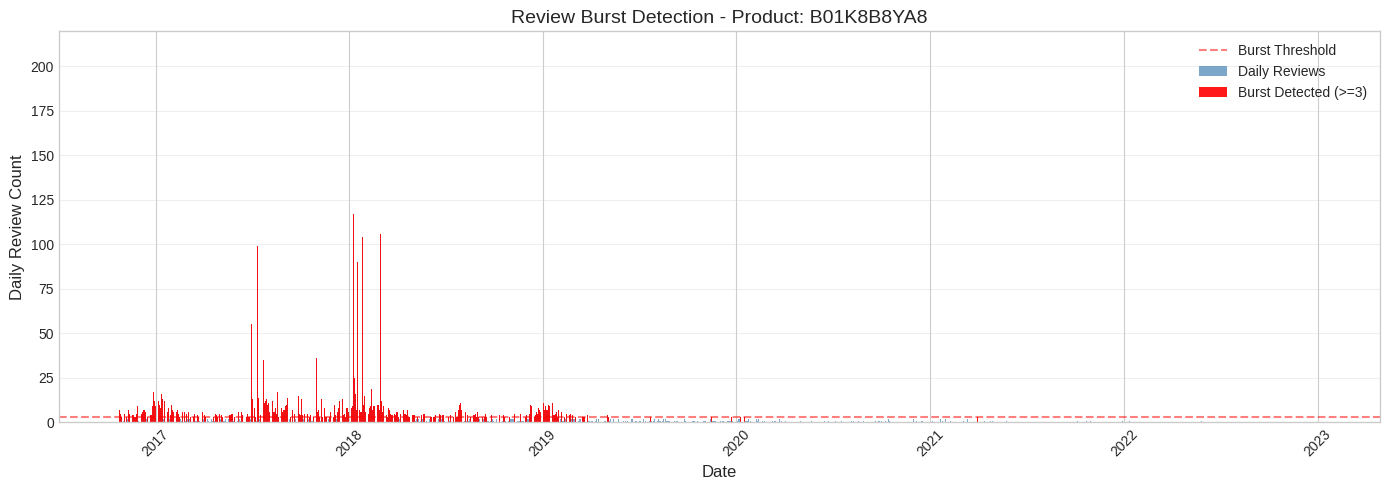

Product B01K8B8YA8: 645 burst days detected


In [ ]:
# Review Burst Visualization
burst_sample = daily_reviews.filter(F.col("is_burst") == 1).orderBy(F.desc("daily_count")).first()

if burst_sample:
    sample_product = burst_sample.parent_asin
    product_daily = daily_reviews.filter(F.col("parent_asin") == sample_product).orderBy("review_date").toPandas()

    plt.figure(figsize=(14, 5))

    # Plot daily reviews
    plt.bar(product_daily['review_date'], product_daily['daily_count'],
            color='steelblue', alpha=0.7, label='Daily Reviews')

    # Highlight burst days
    burst_dates = product_daily[product_daily['is_burst'] == 1]
    plt.bar(burst_dates['review_date'], burst_dates['daily_count'],
            color='red', alpha=0.9, label='Burst Detected (>=3)')

    # Add threshold line
    plt.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Burst Threshold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Daily Review Count', fontsize=12)
    plt.title(f'Review Burst Detection - Product: {sample_product}', fontsize=14)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('review_burst.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Product {sample_product}: {len(burst_dates)} burst days detected")

## Part 6: Layer 5 - Rating Distribution Entropy

In [ ]:
print("\n" + "=" * 60)
print("LAYER 5: Product Rating Distribution Anomaly (Entropy)")
print("=" * 60)

# Calculate rating distribution per product
product_ratings = reviews.groupBy("parent_asin").agg(
    F.count("*").alias("total_reviews"),
    F.avg("rating").alias("avg_rating"),
    F.stddev("rating").alias("rating_std"),
    F.sum(F.when(F.col("rating") == 1.0, 1).otherwise(0)).alias("count_1"),
    F.sum(F.when(F.col("rating") == 2.0, 1).otherwise(0)).alias("count_2"),
    F.sum(F.when(F.col("rating") == 3.0, 1).otherwise(0)).alias("count_3"),
    F.sum(F.when(F.col("rating") == 4.0, 1).otherwise(0)).alias("count_4"),
    F.sum(F.when(F.col("rating") == 5.0, 1).otherwise(0)).alias("count_5"),
    F.avg("verified_int").alias("pct_verified"),
    F.avg("review_length").alias("avg_review_length")
)

@udf(FloatType())
def calc_entropy(c1, c2, c3, c4, c5):
    try:
        total = c1 + c2 + c3 + c4 + c5
        if total == 0:
            return 0.0
        probs = [c1/total, c2/total, c3/total, c4/total, c5/total]
        entropy = 0.0
        for p in probs:
            if p > 0:
                entropy -= p * np.log2(p)
        return float(entropy / np.log2(5))
    except:
        return 0.0

product_ratings = product_ratings.withColumn(
    "rating_entropy",
    calc_entropy(F.col("count_1"), F.col("count_2"), F.col("count_3"), F.col("count_4"), F.col("count_5"))
).withColumn(
    "pct_5_star", F.col("count_5") / F.col("total_reviews")
).withColumn(
    "suspicious_distribution",
    F.when((F.col("rating_entropy") < 0.3) & (F.col("pct_5_star") > 0.8) & (F.col("total_reviews") >= 10), 1).otherwise(0)
)

suspicious_products = product_ratings.filter(F.col("suspicious_distribution") == 1)
print(f"Products with suspicious rating distribution: {suspicious_products.count():,}")

product_ratings.cache()

print("\nProducts with suspicious distribution:")
product_ratings.filter(F.col("suspicious_distribution") == 1) \
    .orderBy(F.desc("total_reviews")) \
    .select("parent_asin", "total_reviews", "avg_rating", "pct_5_star", "rating_entropy") \
    .show(10)


LAYER 5: Product Rating Distribution Anomaly (Entropy)
Products with suspicious rating distribution: 3,373

Products with suspicious distribution:
+-----------+-------------+------------------+------------------+--------------+
|parent_asin|total_reviews|        avg_rating|        pct_5_star|rating_entropy|
+-----------+-------------+------------------+------------------+--------------+
| B07QN33986|          601|4.9051580698835275|0.9284525790349417|    0.19002749|
| B0BHWQ3H17|          342| 4.748538011695906|0.8888888888888888|     0.2990273|
| B00SFSU53G|          317| 4.798107255520505| 0.889589905362776|     0.2945882|
| B07JMQP6T6|          305| 4.872131147540983|0.9049180327868852|    0.23919222|
| B00OBRE5UE|          304| 4.792763157894737|0.8947368421052632|    0.27896476|
| B07532HKWG|          292|4.8493150684931505|0.9212328767123288|    0.21627893|
| B0B3RVRQKG|          289| 4.788927335640138|0.8996539792387543|    0.27119657|
| B0BZ6XH3LC|          286| 4.856643356643

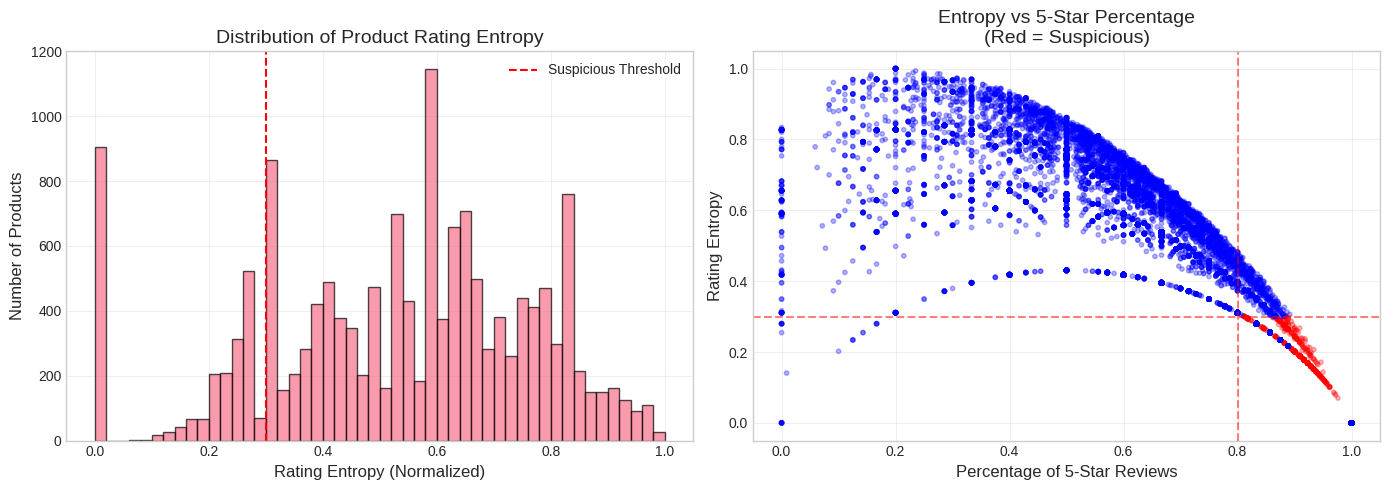

In [ ]:
# Entropy Visualization
entropy_pd = product_ratings.filter(F.col("total_reviews") >= 5) \
    .select("rating_entropy", "pct_5_star", "total_reviews", "suspicious_distribution") \
    .sample(fraction=0.2, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(entropy_pd['rating_entropy'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.3, color='r', linestyle='--', label='Suspicious Threshold')
axes[0].set_xlabel('Rating Entropy (Normalized)', fontsize=12)
axes[0].set_ylabel('Number of Products', fontsize=12)
axes[0].set_title('Distribution of Product Rating Entropy', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

colors = ['red' if x == 1 else 'blue' for x in entropy_pd['suspicious_distribution']]
axes[1].scatter(entropy_pd['pct_5_star'], entropy_pd['rating_entropy'], c=colors, alpha=0.3, s=10)
axes[1].axhline(y=0.3, color='r', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.8, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Percentage of 5-Star Reviews', fontsize=12)
axes[1].set_ylabel('Rating Entropy', fontsize=12)
axes[1].set_title('Entropy vs 5-Star Percentage\n(Red = Suspicious)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('entropy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 7: Layer 6 - Comprehensive Trust Index

In [ ]:
print("\n" + "=" * 60)
print("LAYER 6: Comprehensive Trust Index Calculation")
print("=" * 60)

# User Trust Score
print("\n--- Calculating User Trust Score ---")

user_trust = user_clustered.select(
    "user_id", "user_cluster", "is_suspicious_cluster", "review_count",
    "pct_verified", "pct_5_star", "avg_helpful_votes", "rating_std", "avg_review_length"
)

user_trust = user_trust.join(
    user_similarity.select("user_id", "avg_text_similarity"), on="user_id", how="left"
).fillna({"avg_text_similarity": 0.0})

user_trust = user_trust.withColumn(
    "verified_score", F.col("pct_verified")
).withColumn(
    "helpful_score", F.least(F.col("avg_helpful_votes") / 5.0, F.lit(1.0))
).withColumn(
    "diversity_score", F.least(F.col("rating_std") / 2.0, F.lit(1.0))
).withColumn(
    "length_score",
    F.when(F.col("avg_review_length") >= 200, 1.0)
    .when(F.col("avg_review_length") >= 100, 0.7)
    .when(F.col("avg_review_length") >= 50, 0.4)
    .otherwise(0.2)
).withColumn(
    "similarity_penalty",
    F.when(F.col("avg_text_similarity") > 0.5, -0.3)
    .when(F.col("avg_text_similarity") > 0.3, -0.1)
    .otherwise(0.0)
).withColumn(
    "extreme_penalty",
    F.when(F.col("pct_5_star") > 0.9, -0.3)
    .when(F.col("pct_5_star") > 0.8, -0.15)
    .otherwise(0.0)
).withColumn(
    "cluster_penalty",
    F.when(F.col("is_suspicious_cluster") == 1, -0.3).otherwise(0.0)
)

user_trust = user_trust.withColumn(
    "user_trust_score",
    F.greatest(F.lit(0.0), F.least(F.lit(1.0),
        F.lit(0.3) + F.lit(0.2) * F.col("verified_score") + F.lit(0.15) * F.col("helpful_score") +
        F.lit(0.15) * F.col("diversity_score") + F.lit(0.2) * F.col("length_score") +
        F.col("similarity_penalty") + F.col("extreme_penalty") + F.col("cluster_penalty")
    ))
)

user_trust_final = user_trust.select("user_id", "user_cluster", "user_trust_score")
user_trust_final.cache()

print("User Trust Score Distribution:")
user_trust_final.describe("user_trust_score").show()


LAYER 6: Comprehensive Trust Index Calculation

--- Calculating User Trust Score ---
User Trust Score Distribution:
+-------+-------------------+
|summary|   user_trust_score|
+-------+-------------------+
|  count|              43974|
|   mean| 0.5987470661107257|
| stddev|0.23326737896117378|
|    min|                0.0|
|    max|                1.0|
+-------+-------------------+



In [ ]:
# Review Trust Score
print("\n--- Calculating Review Trust Score ---")

review_trust = reviews_sentiment.select(
    "user_id", "parent_asin", "asin", "rating", "text", "review_length",
    "verified_int", "has_image", "helpful_vote", "sentiment_score", "suspicious_sentiment"
)

review_trust = review_trust.join(
    user_trust_final.select("user_id", "user_trust_score"), on="user_id", how="left"
).fillna({"user_trust_score": 0.5})

review_trust = review_trust.join(
    product_ratings.select("parent_asin", "rating_entropy", "suspicious_distribution"),
    on="parent_asin", how="left"
).fillna({"rating_entropy": 0.5, "suspicious_distribution": 0})

review_trust = review_trust.withColumn(
    "length_score",
    F.when(F.col("review_length") >= 200, 1.0)
    .when(F.col("review_length") >= 100, 0.7)
    .when(F.col("review_length") >= 50, 0.4)
    .otherwise(0.1)
).withColumn(
    "verified_bonus", F.when(F.col("verified_int") == 1, 0.15).otherwise(0.0)
).withColumn(
    "image_bonus", F.when(F.col("has_image") == 1, 0.1).otherwise(0.0)
).withColumn(
    "helpful_bonus",
    F.when(F.col("helpful_vote") > 5, 0.15)
    .when(F.col("helpful_vote") > 0, 0.05)
    .otherwise(0.0)
).withColumn(
    "sentiment_penalty", F.when(F.col("suspicious_sentiment") == 1, -0.25).otherwise(0.0)
).withColumn(
    "product_penalty", F.when(F.col("suspicious_distribution") == 1, -0.15).otherwise(0.0)
)

review_trust = review_trust.withColumn(
    "review_trust_score",
    F.greatest(F.lit(0.0), F.least(F.lit(1.0),
        F.lit(0.2) + F.lit(0.15) * F.col("length_score") + F.lit(0.35) * F.col("user_trust_score") +
        F.lit(0.15) * F.col("rating_entropy") + F.col("verified_bonus") + F.col("image_bonus") +
        F.col("helpful_bonus") + F.col("sentiment_penalty") + F.col("product_penalty")
    ))
)

review_trust_final = review_trust.select(
    "user_id", "parent_asin", "asin", "rating", "text",
    "user_trust_score", "review_trust_score",
    "verified_int", "has_image", "helpful_vote",
    "sentiment_score", "suspicious_sentiment", "suspicious_distribution"
)
review_trust_final.cache()

print("Review Trust Score Distribution:")
review_trust_final.describe("review_trust_score").show()


--- Calculating Review Trust Score ---
Review Trust Score Distribution:
+-------+--------------------+
|summary|  review_trust_score|
+-------+--------------------+
|  count|              658684|
|   mean|  0.6800589081750085|
| stddev| 0.11084480904950296|
|    min|0.009854094088077608|
|    max|                 1.0|
+-------+--------------------+



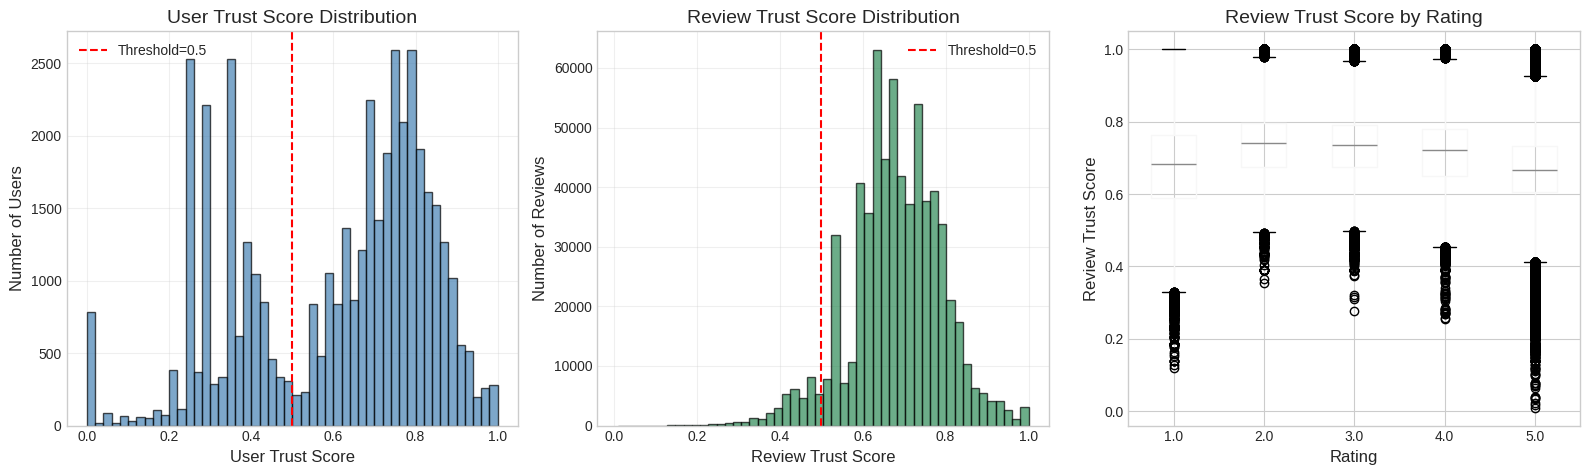

In [ ]:
# Trust Index Visualization
user_trust_pd = user_trust_final.select("user_trust_score").toPandas()
review_trust_pd = review_trust_final.select("review_trust_score", "rating").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(user_trust_pd['user_trust_score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.5, color='r', linestyle='--', label='Threshold=0.5')
axes[0].set_xlabel('User Trust Score', fontsize=12)
axes[0].set_ylabel('Number of Users', fontsize=12)
axes[0].set_title('User Trust Score Distribution', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(review_trust_pd['review_trust_score'], bins=50, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].axvline(x=0.5, color='r', linestyle='--', label='Threshold=0.5')
axes[1].set_xlabel('Review Trust Score', fontsize=12)
axes[1].set_ylabel('Number of Reviews', fontsize=12)
axes[1].set_title('Review Trust Score Distribution', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

review_trust_pd.boxplot(column='review_trust_score', by='rating', ax=axes[2])
axes[2].set_xlabel('Rating', fontsize=12)
axes[2].set_ylabel('Review Trust Score', fontsize=12)
axes[2].set_title('Review Trust Score by Rating', fontsize=14)
plt.suptitle('')

plt.tight_layout()
plt.savefig('trust_index_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 8: Model Evaluation


MODEL EVALUATION
Silhouette Score: 0.4432


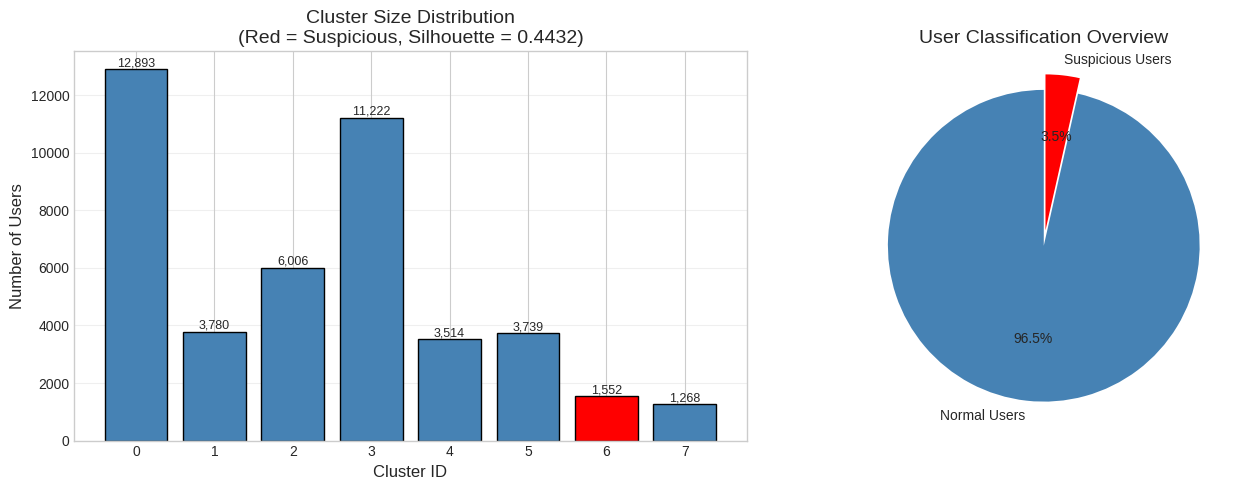

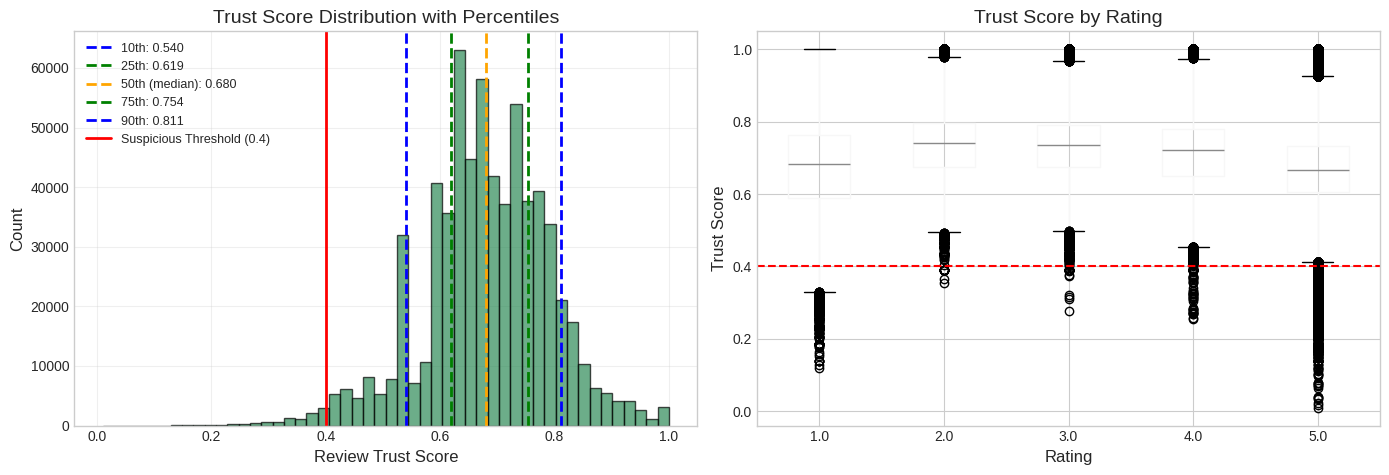


Trust Score Percentiles:
  10th: 0.540
  25th: 0.619
  50th: 0.680
  75th: 0.754
  90th: 0.811


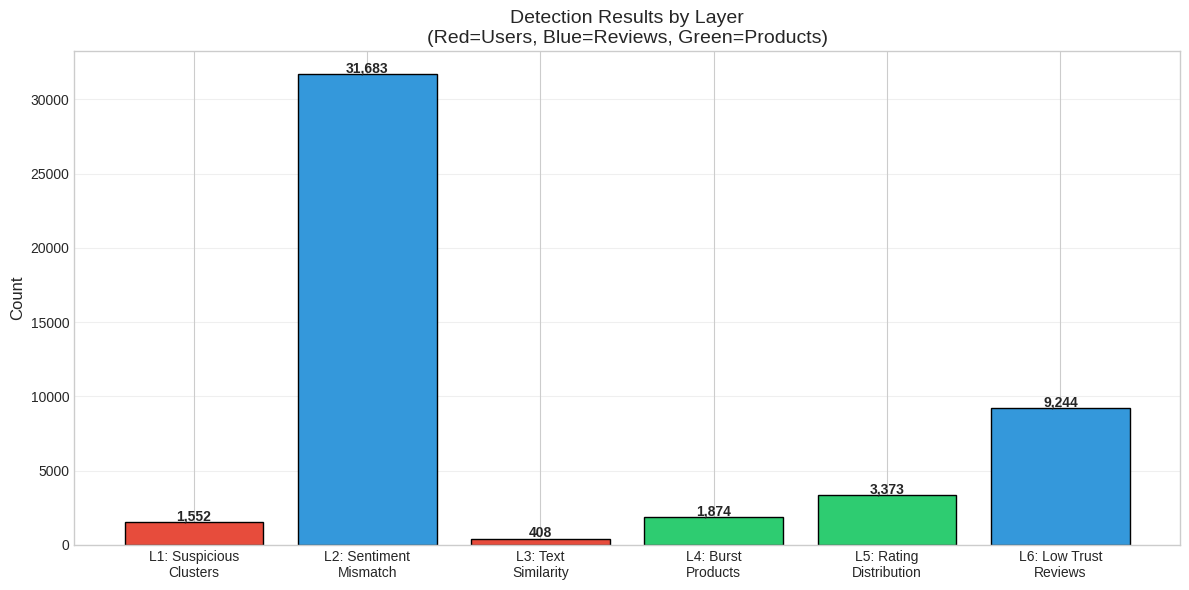

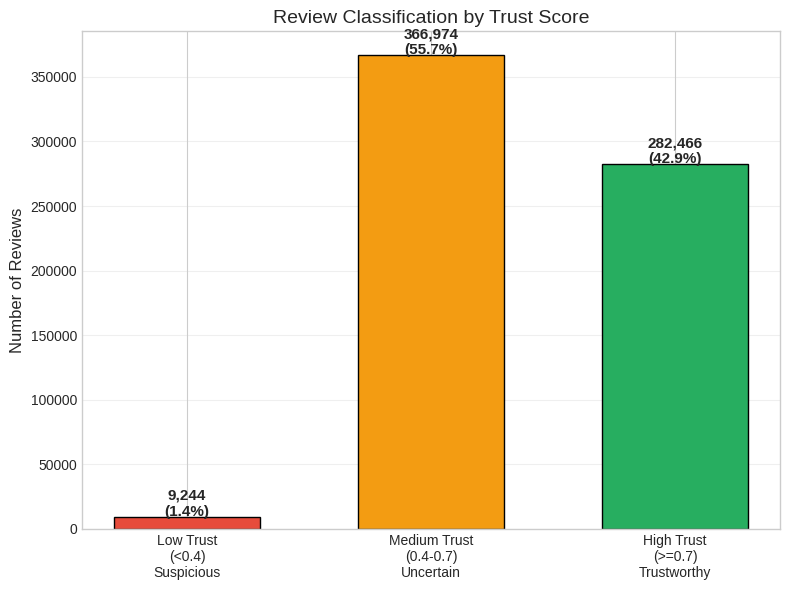


EVALUATION SUMMARY

Clustering Quality:
  - Silhouette Score: 0.4432 (Range: -1 to 1, higher = better)
  - Number of Clusters: 8

Detection Coverage:
  - Total Users Analyzed: 43,974
  - Total Reviews Analyzed: 658,684

Classification Results:
  - Low Trust (Suspicious): 9,244 (1.4%)
  - Medium Trust (Uncertain): 366,974 (55.7%)
  - High Trust (Trustworthy): 282,466 (42.9%)



In [ ]:
# ============================================================
# MODEL EVALUATION WITH VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# 1. Clustering Quality
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    predictionCol="user_cluster",
    featuresCol="features",
    metricName="silhouette"
)
silhouette = evaluator.evaluate(user_clustered)
print(f"Silhouette Score: {silhouette:.4f}")

# 2. Cluster Distribution Visualization
cluster_counts = user_clustered.groupBy("user_cluster").agg(
    F.count("*").alias("count"),
    F.sum("is_suspicious_cluster").alias("suspicious_count")
).orderBy("user_cluster").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - Cluster sizes
colors = ['red' if cluster_counts.loc[i, 'suspicious_count'] > 0 else 'steelblue'
          for i in range(len(cluster_counts))]
axes[0].bar(cluster_counts['user_cluster'], cluster_counts['count'], color=colors, edgecolor='black')
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Number of Users', fontsize=12)
axes[0].set_title(f'Cluster Size Distribution\n(Red = Suspicious, Silhouette = {silhouette:.4f})', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Add count labels
for i, v in enumerate(cluster_counts['count']):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Pie chart - Suspicious vs Normal
suspicious_total = cluster_counts['suspicious_count'].sum()
normal_total = cluster_counts['count'].sum() - suspicious_total
axes[1].pie([normal_total, suspicious_total],
            labels=['Normal Users', 'Suspicious Users'],
            autopct='%1.1f%%', colors=['steelblue', 'red'],
            explode=[0, 0.1], startangle=90)
axes[1].set_title('User Classification Overview', fontsize=14)

plt.tight_layout()
plt.savefig('evaluation_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Trust Index Distribution with Percentiles
trust_pd = review_trust_final.select("review_trust_score").toPandas()
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9]
percentile_values = trust_pd['review_trust_score'].quantile(percentiles).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with percentile lines
axes[0].hist(trust_pd['review_trust_score'], bins=50, edgecolor='black', alpha=0.7, color='seagreen')
colors_p = ['blue', 'green', 'orange', 'green', 'blue']
labels_p = ['10th', '25th', '50th (median)', '75th', '90th']
for pv, c, lb in zip(percentile_values, colors_p, labels_p):
    axes[0].axvline(x=pv, color=c, linestyle='--', linewidth=2, label=f'{lb}: {pv:.3f}')
axes[0].axvline(x=0.4, color='red', linestyle='-', linewidth=2, label='Suspicious Threshold (0.4)')
axes[0].set_xlabel('Review Trust Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Trust Score Distribution with Percentiles', fontsize=14)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Box plot by rating
review_trust_box = review_trust_final.select("review_trust_score", "rating").toPandas()
review_trust_box.boxplot(column='review_trust_score', by='rating', ax=axes[1])
axes[1].axhline(y=0.4, color='red', linestyle='--', label='Threshold')
axes[1].set_xlabel('Rating', fontsize=12)
axes[1].set_ylabel('Trust Score', fontsize=12)
axes[1].set_title('Trust Score by Rating', fontsize=14)
plt.suptitle('')

plt.tight_layout()
plt.savefig('evaluation_trust_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print percentiles
print("\nTrust Score Percentiles:")
for p, v in zip(['10th', '25th', '50th', '75th', '90th'], percentile_values):
    print(f"  {p}: {v:.3f}")

# 4. Detection Rates by Layer - Bar Chart
detection_data = {
    'Layer': ['L1: Suspicious\nClusters', 'L2: Sentiment\nMismatch', 'L3: Text\nSimilarity',
              'L4: Burst\nProducts', 'L5: Rating\nDistribution', 'L6: Low Trust\nReviews'],
    'Count': [suspicious_user_count, suspicious_sentiment_count, suspicious_text_users.count(),
              burst_count, suspicious_products.count(), low_trust_reviews],
    'Type': ['Users', 'Reviews', 'Users', 'Products', 'Products', 'Reviews']
}
detection_df = pd.DataFrame(detection_data)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(detection_df['Layer'], detection_df['Count'],
              color=['#e74c3c', '#3498db', '#e74c3c', '#2ecc71', '#2ecc71', '#3498db'],
              edgecolor='black')

# Add value labels
for bar, count in zip(bars, detection_df['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Detection Results by Layer\n(Red=Users, Blue=Reviews, Green=Products)', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('evaluation_detection_layers.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Confusion Matrix Style - Trust Score Classification
low_trust = trust_pd[trust_pd['review_trust_score'] < 0.4].shape[0]
medium_trust = trust_pd[(trust_pd['review_trust_score'] >= 0.4) & (trust_pd['review_trust_score'] < 0.7)].shape[0]
high_trust = trust_pd[trust_pd['review_trust_score'] >= 0.7].shape[0]

fig, ax = plt.subplots(figsize=(8, 6))
categories = ['Low Trust\n(<0.4)\nSuspicious', 'Medium Trust\n(0.4-0.7)\nUncertain', 'High Trust\n(>=0.7)\nTrustworthy']
counts = [low_trust, medium_trust, high_trust]
colors = ['#e74c3c', '#f39c12', '#27ae60']

bars = ax.bar(categories, counts, color=colors, edgecolor='black', width=0.6)
for bar, count in zip(bars, counts):
    percentage = count / len(trust_pd) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}\n({percentage:.1f}%)', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Review Classification by Trust Score', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('evaluation_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Summary Statistics
print("\n" + "=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"""
Clustering Quality:
  - Silhouette Score: {silhouette:.4f} (Range: -1 to 1, higher = better)
  - Number of Clusters: {optimal_k}

Detection Coverage:
  - Total Users Analyzed: {user_clustered.count():,}
  - Total Reviews Analyzed: {review_trust_final.count():,}

Classification Results:
  - Low Trust (Suspicious): {low_trust:,} ({low_trust/len(trust_pd)*100:.1f}%)
  - Medium Trust (Uncertain): {medium_trust:,} ({medium_trust/len(trust_pd)*100:.1f}%)
  - High Trust (Trustworthy): {high_trust:,} ({high_trust/len(trust_pd)*100:.1f}%)
""")

## Part 9: Final Summary

In [ ]:
print("\n" + "=" * 80)
print("FINAL SUMMARY: FAKE REVIEW DETECTION RESULTS")
print("=" * 80)

total_reviews = reviews.count()
total_users = user_features.count()
active_users_count = user_clustered.count()

suspicious_users = user_trust_final.filter(F.col("user_trust_score") < 0.4).count()
low_trust_reviews = review_trust_final.filter(F.col("review_trust_score") < 0.4).count()
total_analyzed_reviews = review_trust_final.count()

print(f"""
Dataset Overview:
-----------------
Total Reviews:           {total_reviews:,}
Total Users:             {total_users:,}
Active Users (>=3 reviews): {active_users_count:,}

Detection Results:
------------------
Layer 1 - User Clustering:
  - Suspicious clusters: {suspicious_cluster_ids}
  - Users in suspicious clusters: {suspicious_user_count:,}

Layer 2 - Sentiment Analysis:
  - Reviews with suspicious sentiment: {suspicious_sentiment_count:,}

Layer 3 - Text Similarity:
  - Users with high text similarity: {suspicious_text_users.count():,}

Layer 4 - Review Burst:
  - Products with burst patterns: {burst_count:,}
  - Reviews during bursts: {burst_reviews.count():,}

Layer 5 - Rating Distribution:
  - Products with suspicious distribution: {suspicious_products.count():,}

Layer 6 - Trust Index:
  - Low trust users (score < 0.4): {suspicious_users:,} ({suspicious_users/active_users_count*100:.1f}%)
  - Low trust reviews (score < 0.4): {low_trust_reviews:,} ({low_trust_reviews/total_analyzed_reviews*100:.1f}%)

Key Insights:
-------------
1. Approximately {suspicious_users/active_users_count*100:.1f}% of active users show suspicious patterns
2. {low_trust_reviews/total_analyzed_reviews*100:.1f}% of analyzed reviews have low trust scores
3. Products with review bursts may indicate coordinated fake review campaigns
4. Low entropy + high 5-star percentage is a strong indicator of manipulation
""")


FINAL SUMMARY: FAKE REVIEW DETECTION RESULTS

Dataset Overview:
-----------------
Total Reviews:           2,193,853
Total Users:             1,923,112
Active Users (>=3 reviews): 43,974

Detection Results:
------------------
Layer 1 - User Clustering:
  - Suspicious clusters: [6]
  - Users in suspicious clusters: 1,552

Layer 2 - Sentiment Analysis:
  - Reviews with suspicious sentiment: 31,683

Layer 3 - Text Similarity:
  - Users with high text similarity: 408

Layer 4 - Review Burst:
  - Products with burst patterns: 1,874
  - Reviews during bursts: 441,692

Layer 5 - Rating Distribution:
  - Products with suspicious distribution: 3,373

Layer 6 - Trust Index:
  - Low trust users (score < 0.4): 11,933 (27.1%)
  - Low trust reviews (score < 0.4): 9,244 (1.4%)

Key Insights:
-------------
1. Approximately 27.1% of active users show suspicious patterns
2. 1.4% of analyzed reviews have low trust scores
3. Products with review bursts may indicate coordinated fake review campaigns
4. Lo

In [ ]:
# Export Results
print("\n--- Exporting Results ---")

suspicious_users_df = user_trust_final.filter(F.col("user_trust_score") < 0.4)
suspicious_users_pd = suspicious_users_df.toPandas()
suspicious_users_pd.to_csv('suspicious_users.csv', index=False)
print(f"Exported: suspicious_users.csv ({len(suspicious_users_pd):,} rows)")

low_trust_reviews_df = review_trust_final.filter(F.col("review_trust_score") < 0.4)
low_trust_reviews_pd = low_trust_reviews_df.limit(10000).toPandas()
low_trust_reviews_pd.to_csv('low_trust_reviews.csv', index=False)
print(f"Exported: low_trust_reviews.csv ({len(low_trust_reviews_pd):,} rows)")

cluster_stats_pd.to_csv('cluster_statistics.csv', index=False)
print("Exported: cluster_statistics.csv")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("""
Generated Files:
- elbow_silhouette.png
- cluster_heatmap.png
- sentiment_analysis.png
- text_similarity.png
- review_burst.png
- entropy_analysis.png
- trust_index_distribution.png
- suspicious_users.csv
- low_trust_reviews.csv
- cluster_statistics.csv
""")


--- Exporting Results ---
Exported: suspicious_users.csv (11,933 rows)
Exported: low_trust_reviews.csv (9,244 rows)
Exported: cluster_statistics.csv

ANALYSIS COMPLETE!

Generated Files:
- elbow_silhouette.png
- cluster_heatmap.png
- sentiment_analysis.png
- text_similarity.png
- review_burst.png
- entropy_analysis.png
- trust_index_distribution.png
- suspicious_users.csv
- low_trust_reviews.csv
- cluster_statistics.csv



In [ ]:
# Export results for Streamlit Demo
print("Exporting results for demo...")

# Save to Google Drive
output_path = "/content/drive/MyDrive/fake_review_demo/"
!mkdir -p {output_path}

# Export CSVs
suspicious_users_pd.to_csv(f'{output_path}suspicious_users.csv', index=False)
low_trust_reviews_pd.to_csv(f'{output_path}low_trust_reviews.csv', index=False)
cluster_stats_pd.to_csv(f'{output_path}cluster_statistics.csv', index=False)

# Copy images
!cp *.png {output_path}

print(f"All files exported to: {output_path}")
!ls -la {output_path}

Exporting results for demo...
All files exported to: /content/drive/MyDrive/fake_review_demo/
total 4390
-rw------- 1 root root  113144 Dec  4 23:11 cluster_heatmap.png
-rw------- 1 root root  408459 Dec  4 23:11 cluster_pca_scatter.png
-rw------- 1 root root    1377 Dec  4 23:11 cluster_statistics.csv
-rw------- 1 root root  123143 Dec  4 23:11 elbow_silhouette.png
-rw------- 1 root root  235613 Dec  4 23:11 entropy_analysis.png
-rw------- 1 root root   66931 Dec  4 23:11 evaluation_classification.png
-rw------- 1 root root   87129 Dec  4 23:11 evaluation_clusters.png
-rw------- 1 root root   72430 Dec  4 23:11 evaluation_detection_layers.png
-rw------- 1 root root   99725 Dec  4 23:11 evaluation_trust_distribution.png
-rw------- 1 root root 2379388 Dec  4 23:11 low_trust_reviews.csv
-rw------- 1 root root   60903 Dec  4 23:11 review_burst.png
-rw------- 1 root root   77511 Dec  4 23:11 sentiment_analysis.png
-rw------- 1 root root  560493 Dec  4 23:11 suspicious_users.csv
-rw------- 

## Part X: Recommendations on Trusted Reviews
Use the existing `review_trust_final` to build ALS recommendations on trusted reviews.



In [ ]:
# Recommendation System on Trusted Reviews
# Assumes `review_trust_final` exists with columns: user_id, parent_asin, rating, review_trust_score
# Keep Electronics only if your earlier pipeline filtered; otherwise, it will use all.

from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

# 1) Filter trusted reviews
trust_threshold = 0.7
trusted_reviews = review_trust_final.filter(F.col("review_trust_score") >= trust_threshold)

print("Trusted reviews stats:")
total_reviews = review_trust_final.count()
trusted_count = trusted_reviews.count()
print(f"  Total analyzed: {total_reviews:,}")
print(f"  Trusted (>= {trust_threshold}): {trusted_count:,} ({trusted_count/total_reviews*100:.1f}%)")

# 2) Prepare user-item data
user_item = trusted_reviews.select("user_id", "parent_asin", "rating") \
    .filter(F.col("user_id").isNotNull() & F.col("parent_asin").isNotNull() & F.col("rating").isNotNull())

# Index users/items
user_indexer = StringIndexer(inputCol="user_id", outputCol="user_index", handleInvalid="skip")
item_indexer = StringIndexer(inputCol="parent_asin", outputCol="item_index", handleInvalid="skip")

user_item = user_indexer.fit(user_item).transform(user_item)
user_item = item_indexer.fit(user_item).transform(user_item)

user_item = user_item.withColumn("user_index", F.col("user_index").cast("int")) \
                     .withColumn("item_index", F.col("item_index").cast("int")) \
                     .withColumn("rating", F.col("rating").cast("float"))

print(f"Prepared interactions: {user_item.count():,}")
print(f"Unique users: {user_item.select('user_index').distinct().count():,}")
print(f"Unique items: {user_item.select('item_index').distinct().count():,}")

# 3) Train/test split
train, test = user_item.randomSplit([0.8, 0.2], seed=42)

# 4) Train ALS
als = ALS(
    maxIter=10,
    regParam=0.1,
    userCol="user_index",
    itemCol="item_index",
    ratingCol="rating",
    coldStartStrategy="drop"
)

print("Training ALS...")
als_model = als.fit(train)
print("✅ ALS trained")

# 5) Evaluate
preds = als_model.transform(test).filter(F.col("prediction").isNotNull())
rmse = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction").evaluate(preds)
print(f"✅ RMSE: {rmse:.4f}")

# 6) Generate recommendations
recs = als_model.recommendForAllUsers(10)
print("Sample recommendations:")
recs.show(5, truncate=False)

# 7) Save outputs (optional)
# reenabled if desired
# als_model.write().overwrite().save("als_model_trusted")
# recs.write.mode("overwrite").parquet("recommendations_trusted.parquet")
# trusted_reviews.select("user_id","parent_asin","rating","review_trust_score").write.mode("overwrite").parquet("trusted_reviews.parquet")



# Part 2: Trusted Recommendation System
Now that we have identified trusted reviews, we will build a recommendation system using only the high-quality data.

In [ ]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# 1. Load Trusted Reviews (if not already in memory)
# Assuming 'df_final' is the dataframe from previous steps with 'review_trust_score'
# If running fresh, uncomment below:
# df_final = spark.read.parquet('trusted_reviews.parquet')

# 2. Filter for High Trust
TRUST_THRESHOLD = 0.7
trusted_df = df_final.filter(F.col("review_trust_score") >= TRUST_THRESHOLD)
print(f"Training on {trusted_df.count()} trusted reviews...")

# 3. Index User and Item IDs
user_indexer = StringIndexer(inputCol="user_id", outputCol="user_index", handleInvalid="skip")
item_indexer = StringIndexer(inputCol="asin", outputCol="item_index", handleInvalid="skip")
pipeline = Pipeline(stages=[user_indexer, item_indexer])
model_indexer = pipeline.fit(trusted_df)
indexed_df = model_indexer.transform(trusted_df)

# 4. Train ALS Model
(training, test) = indexed_df.randomSplit([0.8, 0.2], seed=42)
als = ALS(
    maxIter=10, 
    regParam=0.1, 
    userCol="user_index", 
    itemCol="item_index", 
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True
)
model = als.fit(training)

# 5. Evaluate
predictions = model.transform(test)
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print(f"Root-mean-square error (RMSE) on Trusted Data: {rmse:.4f}")

# 6. Generate Recommendations
userRecs = model.recommendForAllUsers(5)
userRecs.show(5, truncate=False)

# 7. Save Recommendations for App
userRecs.write.mode("overwrite").parquet("user_recommendations.parquet")
print("Recommendations saved to user_recommendations.parquet")

# Part 3: Streamlit Application
We will now create the Streamlit app directly from this notebook and run it.

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import os

st.set_page_config(page_title="Trusted Reviews & Recommendations", layout="wide")
st.title("🛡️ Trusted Product Recommendations")

st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Home", "Fake Detection", "Recommendations"])

if page == "Home":
    st.write("### Welcome to the Trusted Review System")
    st.write("This system filters out fake reviews to provide better product recommendations.")
    st.info("Navigate to the other pages to see the results.")

elif page == "Fake Detection":
    st.header("Fake Review Detection")
    if os.path.exists("trusted_reviews.parquet"):
        try:
            df = pd.read_parquet("trusted_reviews.parquet")
            st.write("### Trust Score Distribution")
            st.bar_chart(df['review_trust_score'].value_counts(bins=20).sort_index())
            st.metric("Total Trusted Reviews", len(df))
        except Exception as e:
            st.error(f"Error loading data: {e}")
    else:
        st.warning("trusted_reviews.parquet not found. Run the notebook first.")

elif page == "Recommendations":
    st.header("Your Recommendations")
    if os.path.exists("user_recommendations.parquet"):
        try:
            recs = pd.read_parquet("user_recommendations.parquet")
            st.write("### Sample Recommendations")
            st.dataframe(recs.head(10))
        except Exception as e:
            st.error(f"Error loading recommendations: {e}")
    else:
        st.warning("user_recommendations.parquet not found. Run the notebook first.")

### Run the App
Run the following cell to launch the app. Note: This will block the notebook kernel until you stop it.

In [ ]:
!streamlit run app.py